### Контрольная работа по дисциплине "Современный языки и технологии программирования" Голопят София Александровна ВИИМ32 Вариант 3

In [24]:
from sympy import *
init_printing(use_latex=True)

##  1. Вычислить предел: $\lim\limits_{x\to\infty}(1+\frac{5}{x})^{3x}$

In [25]:
x = symbols('x')
y = Limit((1 + 5 / x) ** (3 * x), x, oo)
Eq(y, y.doit())

## Задание 1. Найти предел функции
$$\lim_{x\to0}\frac{1-\cos 6x}{x\sin x}$$

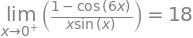

In [26]:
x = symbols('x')
y = Limit((1 - cos(6*x)) / (x * sin(x)), x, 0)
Eq(y, y.doit())

## Задание 2. Вычислить неопределённый интеграл
$$\int \frac{x+3}{\sqrt{7x^2-1}}\,dx$$

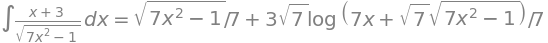

In [27]:
Fx = Integral((x + 3) / sqrt(7*x**2 - 1), x)
Eq(Fx, Fx.doit())

Проверим результат дифференцированием:

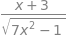

In [28]:
Fx.diff(x)

## Задание 3. Решить систему линейных уравнений
$$
\begin{cases}
x_1+2x_2+x_3+4x_4+x_5=-4,\\
3x_1+2x_2+x_3+x_4-3x_5=1,\\
x_2+2x_3+2x_4+6x_5=-1,\\
5x_1+6x_2+3x_3+9x_4-x_5=-7.
\end{cases}
$$

In [29]:
x1, x2, x3, x4, x5 = symbols('x1 x2 x3 x4 x5')
eq1 = Eq(x1 + 2*x2 + x3 + 4*x4 + x5, -4)
eq2 = Eq(3*x1 + 2*x2 + x3 + x4 - 3*x5, 1)
eq3 = Eq(x2 + 2*x3 + 2*x4 + 6*x5, -1)
eq4 = Eq(5*x1 + 6*x2 + 3*x3 + 9*x4 - x5, -7)
eq1, eq2, eq3, eq4

In [30]:
linsolve([eq1, eq2, eq3, eq4], [x1, x2, x3, x4, x5])

Система содержит 4 уравнения на 5 неизвестных (ранг матрицы меньше числа переменных),
поэтому она **неопределённая**: решение выражается через две свободные переменные
$x_4$ и $x_5$, а $x_1, x_2, x_3$ — базисные переменные.

## Задание 4. Исследовать функцию и построить график
$$y = x^2(x-3)$$

In [31]:
def y(x):
    return x**2 * (x - 3)

x = symbols('x', real=True)

Точки пересечения с осями координат:

In [32]:
rt = solve(y(x), x)
print('Решение уравнения y(x)=0:')
rt

Решение уравнения y(x)=0:


In [33]:
vx = list(rt)
vy = [0] * len(rt)
vx.append(0)
vy.append(y(0))
print('Точки пересечения с осями координат:')
vx, vy

Точки пересечения с осями координат:


Находим производные:

In [34]:
y1 = diff(y(x), x)
print('Первая производная:')
y1 = simplify(y1)
y1

Первая производная:


In [35]:
y2 = diff(y1, x)
print('Вторая производная:')
y2 = simplify(y2)
y2

Вторая производная:


#### Исследование на экстремум

In [36]:
ext = solve(y1, x)
print('Стационарные точки: ')
ext

Стационарные точки: 


In [37]:
y2.subs(x, ext[0])
# важен знак второй производной в первой стационарной точке

In [38]:
y2.subs(x, ext[1])
# важен знак второй производной во второй стационарной точке

В точке $x=0$ вторая производная отрицательна — локальный максимум, $y(0)=0$.
В точке $x=2$ вторая производная положительна — локальный минимум, $y(2)=-4$.

#### Исследование на перегиб

In [39]:
per = solve(y2, x)
print('Точки перегиба: ')
per

Точки перегиба: 


Итак, собираем координаты всех характерных точек графика исследуемой функции:

In [40]:
for p in ext:
    vx.append(p)
    vy.append(y(p))
for p in per:
    vx.append(p)
    vy.append(y(p))
print(vx, vy)

[0, 3, 0, 0, 2, 1] [0, 0, 0, 0, -4, -2]


Строим график:

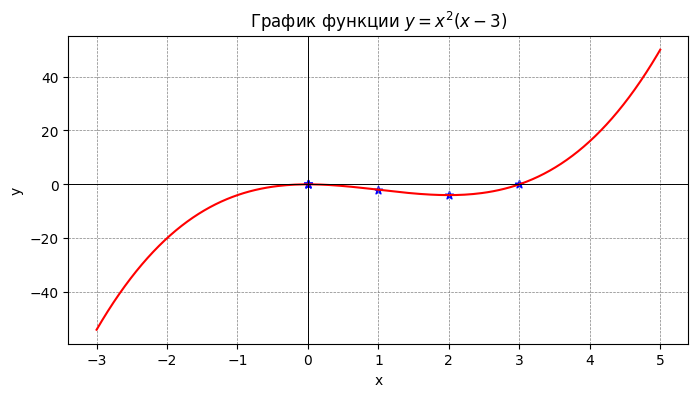

In [41]:
import matplotlib.pyplot as plt
import numpy as np

X = np.linspace(-3, 5, 200)
Y = [float(y(xi)) for xi in X]

vx_f = [float(v) for v in vx]
vy_f = [float(v) for v in vy]

fig = plt.figure(figsize=(8, 4), dpi=100)
plt.plot(X, Y, color='red', linewidth=1.5)
plt.scatter(vx_f, vy_f, marker='*', c='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'График функции $y = x^2(x-3)$')
plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

## Задание 5. Найти общее решение дифференциального уравнения
$$(x^2-4)(y^2-1)y' - xy = 0$$

In [42]:
x = symbols('x')
f = Function('y')
deq = Eq((x**2 - 4) * (f(x)**2 - 1) * f(x).diff(x) - x * f(x), 0)
deq

Уравнение с разделяющимися переменными. Решение по умолчанию:

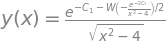

In [43]:
dsolve(deq, f(x))

Результат выражен через неэлементарную функцию LambertW() и неудобен для практики. Посмотрим, какими ещё методами можно решить уравнение:

In [44]:
classify_ode(deq, f(x))

('factorable',
 'separable',
 '1st_exact',
 '1st_power_series',
 'lie_group',
 'separable_Integral',
 '1st_exact_Integral')

In [45]:
dsolve(deq, f(x), hint='1st_exact')

Это и есть наглядное общее решение (в неявном виде):
$$\left(2-\frac{x^2}{2}\right)y^2 e^{-y^2} = C_1$$